In [4]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


DATASET OVERVIEW
Shape of Dataset: (891, 12)

First 5 Records:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123    

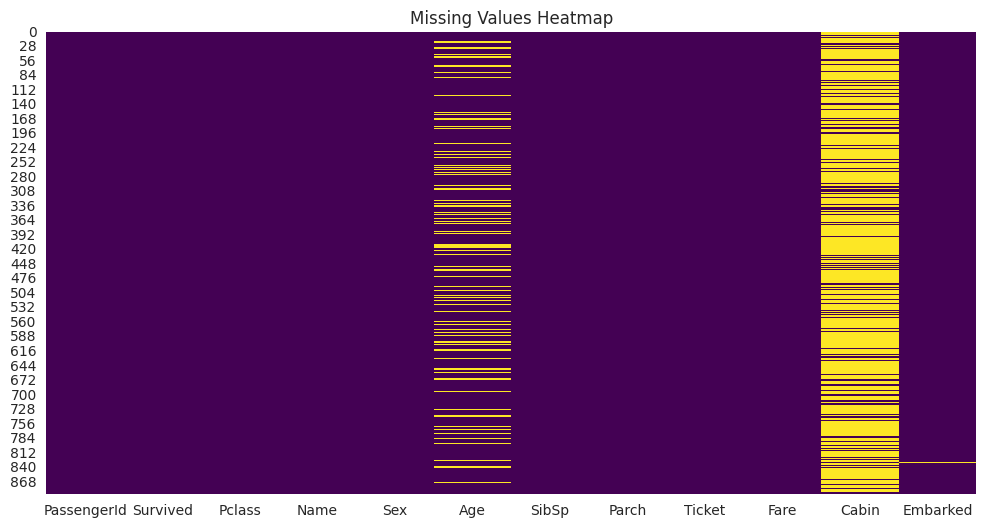


Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

New Features Added:
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


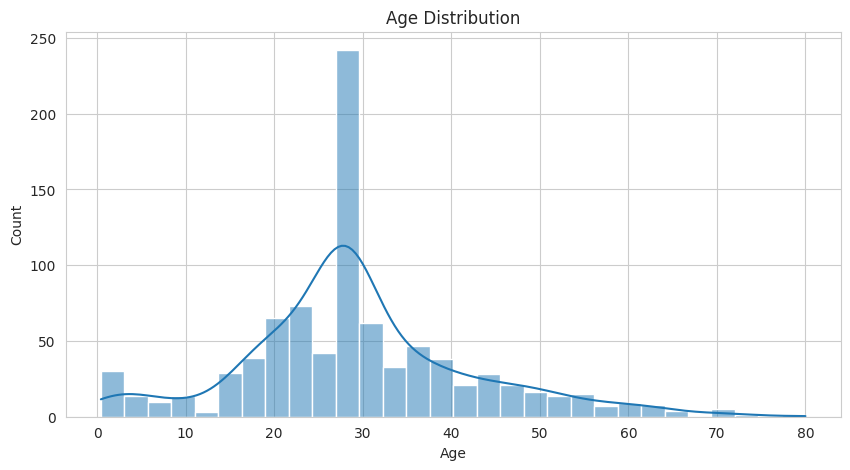

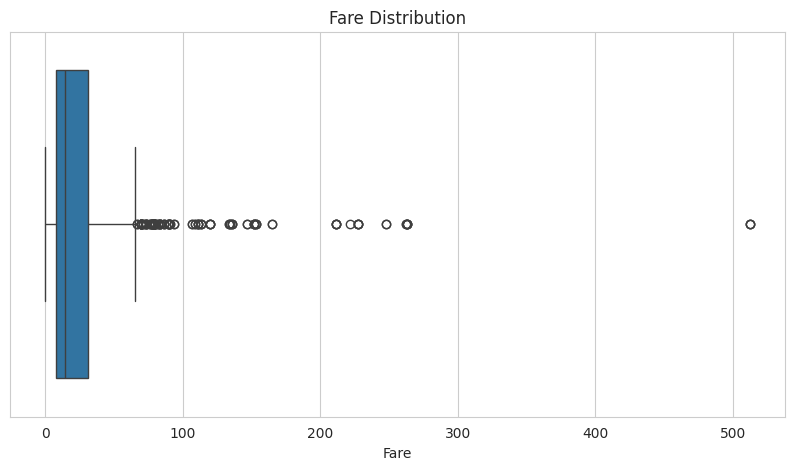

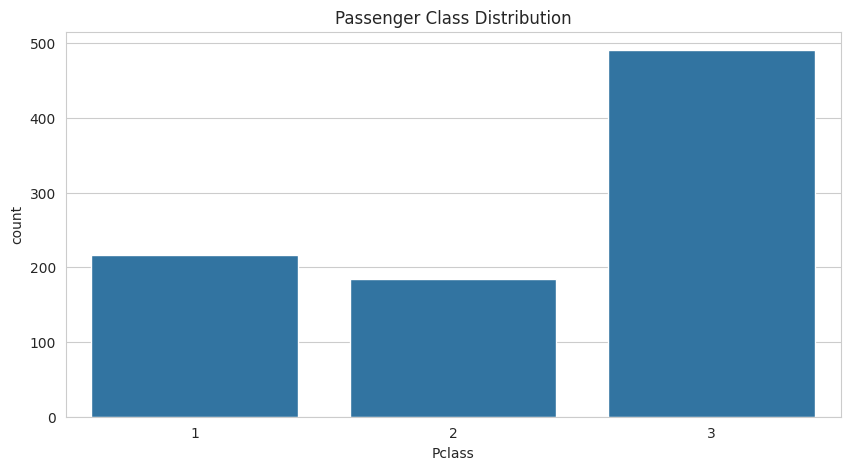

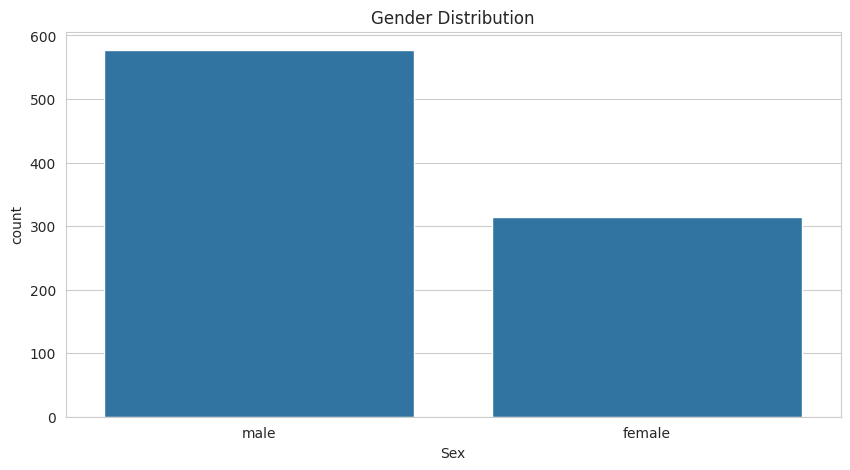


Overall Survival Rate: 38.38 %


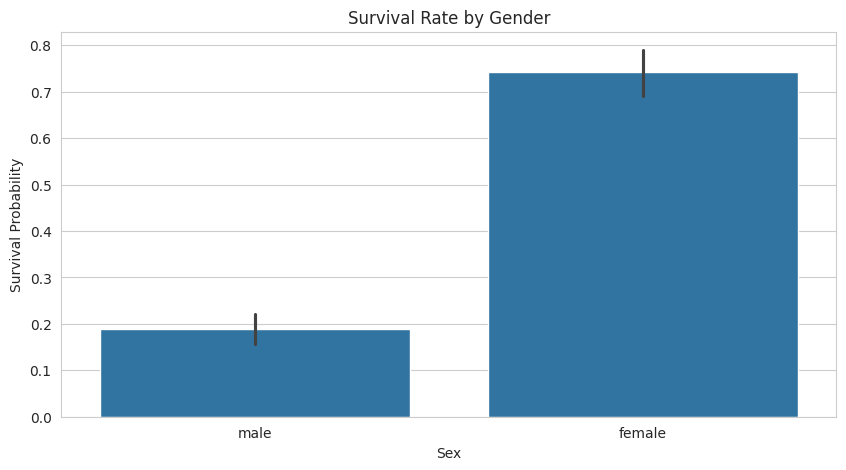

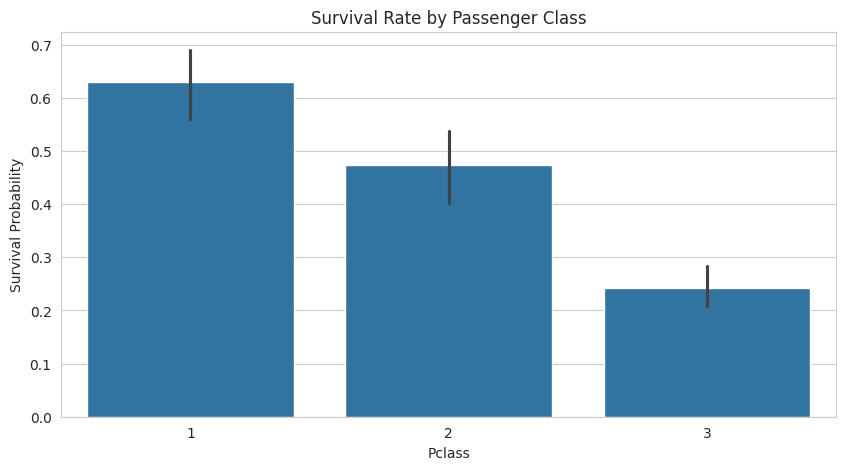

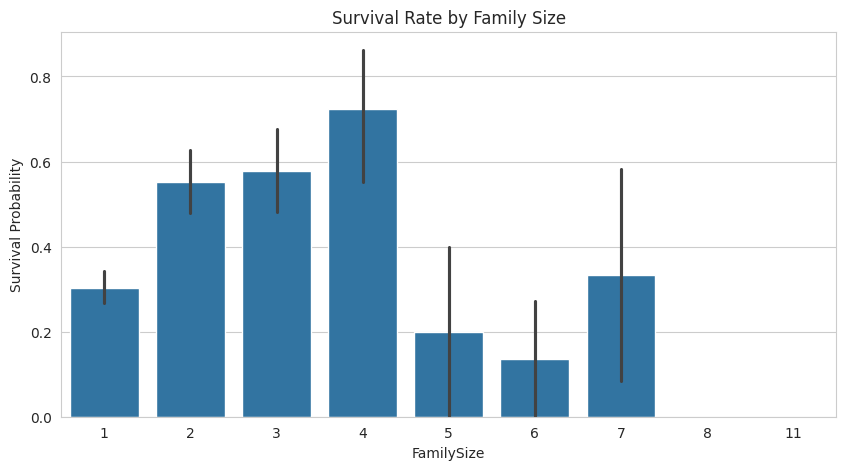

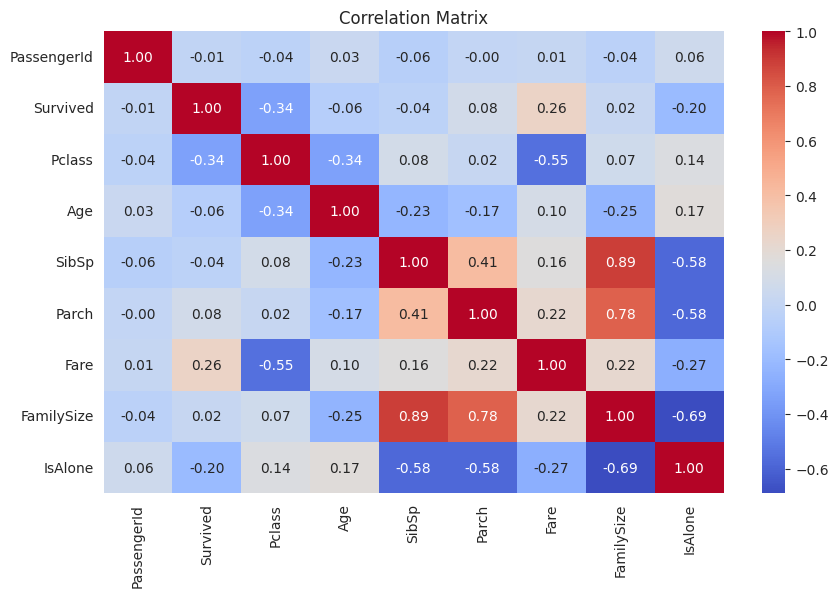


Generating HTML Profiling Report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 52.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML Report Saved Successfully!

KEY INSIGHTS
1. Female passengers had a significantly higher survival rate than males.
2. First-class passengers survived more frequently than second and third class passengers.
3. Most passengers were between 20 and 40 years of age.
4. Fare distribution is highly right-skewed with several outliers.
5. Cabin contained a large number of missing values and was removed.
6. Passenger class strongly influenced survival probability.
7. Family size showed a relationship with survival outcomes.
8. Sex is the strongest predictor of survival in the dataset.

Cleaned Dataset Saved: Titanic_Cleaned.csv
Profiling Report Saved: Titanic_EDA_Report.html

EDA COMPLETED SUCCESSFULLY!


In [5]:
# ==========================================================
# TITANIC DATASET - EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv("Titanic-Dataset.csv")

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Shape of Dataset:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

# =========================
# 3. DATASET INFORMATION
# =========================
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================
# 4. MISSING VALUE ANALYSIS
# =========================
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

print("\nMissing Value Report:")
print(missing_df[missing_df["Missing Values"] > 0])

# Visualize Missing Values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# =========================
# 5. DATA CLEANING
# =========================

# Fill missing Age values using median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Embarked values using mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin column because of excessive missing values
df.drop("Cabin", axis=1, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

# =========================
# 6. FEATURE ENGINEERING
# =========================

# Family size = Self + Parents/Children + Siblings/Spouse
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Create IsAlone feature
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("\nNew Features Added:")
print(df[["FamilySize", "IsAlone"]].head())

# =========================
# 7. UNIVARIATE ANALYSIS
# =========================

# Age Distribution
plt.figure()
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# Fare Distribution
plt.figure()
sns.boxplot(x=df["Fare"])
plt.title("Fare Distribution")
plt.show()

# Passenger Class Distribution
plt.figure()
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Gender Distribution
plt.figure()
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

# =========================
# 8. SURVIVAL ANALYSIS
# =========================

survival_rate = round(df["Survived"].mean()*100,2)

print("\nOverall Survival Rate:", survival_rate,"%")

# Survival by Gender
plt.figure()
sns.barplot(
    data=df,
    x="Sex",
    y="Survived"
)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()

# Survival by Passenger Class
plt.figure()
sns.barplot(
    data=df,
    x="Pclass",
    y="Survived"
)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

# Survival by Family Size
plt.figure()
sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Probability")
plt.show()

# =========================
# 9. CORRELATION ANALYSIS
# =========================

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# =========================
# 10. AUTOMATED PROFILING
# =========================

print("\nGenerating HTML Profiling Report...")

profile = ProfileReport(
    df,
    title="Titanic Exploratory Data Analysis Report",
    explorative=True
)

profile.to_file("Titanic_EDA_Report.html")

print("HTML Report Saved Successfully!")

# =========================
# 11. KEY INSIGHTS
# =========================

print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

print("1. Female passengers had a significantly higher survival rate than males.")
print("2. First-class passengers survived more frequently than second and third class passengers.")
print("3. Most passengers were between 20 and 40 years of age.")
print("4. Fare distribution is highly right-skewed with several outliers.")
print("5. Cabin contained a large number of missing values and was removed.")
print("6. Passenger class strongly influenced survival probability.")
print("7. Family size showed a relationship with survival outcomes.")
print("8. Sex is the strongest predictor of survival in the dataset.")

# =========================
# 12. SAVE CLEANED DATASET
# =========================

df.to_csv("Titanic_Cleaned.csv", index=False)

print("\nCleaned Dataset Saved: Titanic_Cleaned.csv")
print("Profiling Report Saved: Titanic_EDA_Report.html")

print("\nEDA COMPLETED SUCCESSFULLY!")